# Hybrid Apriori Algorithm

**Combination of three techniques:**
- Adaptive starting minsup (calculated from data)
- Per-Item Minimum Support (MIS) for rare vs common items
- Degressive decrease with itemset length (k)

This hybrid version is smarter and more flexible than the original degressive Apriori.

In [1]:
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

### Loading the Data

In [2]:
def charger_donnees(fichier):
    df = pd.read_csv(fichier, header=None, dtype=str)
    transactions = [
        sorted([str(item).strip() for item in row if str(item).strip() != 'nan'])
        for _, row in df.iterrows()
    ]
    return [t for t in transactions if t]

### Support Calculation

In [3]:
def calculer_support(itemset, transactions):
    n = len(transactions)
    if n == 0:
        return 0.0
    return sum(1 for t in transactions if itemset.issubset(t)) / n

### Candidate Generation

In [4]:
def generer_candidats(frequents_prec):
    candidats = []
    ensemble = {frozenset(f) for f in frequents_prec}
    n = len(frequents_prec)

    for i in range(n):
        for j in range(i + 1, n):
            L1, L2 = frequents_prec[i], frequents_prec[j]
            if L1[:-1] != L2[:-1]:
                break
            candidat = L1 + [L2[-1]]

            if all(frozenset(s) in ensemble for s in combinations(candidat, len(candidat) - 1)):
                candidats.append(candidat)

    return candidats

### Hybrid Apriori (Main Algorithm)

In [5]:
def calculer_mis(items_uniques, transactions, base_factor=0.55):
    """Calculate Minimum Item Support (MIS) for each item"""
    mis = {}
    for item in items_uniques:
        sup = calculer_support(frozenset([item]), transactions)
        mis[item] = max(sup * base_factor, 0.03)  # floor to avoid too low
    return mis


def get_required_minsup(itemset, mis_dict, current_minsup_k):
    """Required minsup = max(MIS of its items, current level minsup)"""
    if not itemset:
        return current_minsup_k
    item_mis = [mis_dict.get(item, current_minsup_k) for item in itemset]
    return max(max(item_mis), current_minsup_k)


def apriori_hybrid(transactions, attenuation=0.04, min_confiance=0.7, base_factor=0.55):
    items_uniques = sorted({item for t in transactions for item in t})
    supports = {}
    epsilon = 1e-6

    # Adaptive starting minsup
    one_item_supports = [calculer_support(frozenset([item]), transactions) for item in items_uniques]
    avg_sup = sum(one_item_supports) / len(one_item_supports) if one_item_supports else 0.25
    minsup_initial = max(avg_sup * 0.85, 0.15)

    print(f"Adaptive minsup_initial calculated: {minsup_initial:.4f} (avg 1-item support = {avg_sup:.4f})")

    # Per-Item MIS
    mis_dict = calculer_mis(items_uniques, transactions, base_factor)
    print(f"Per-item MIS calculated for {len(mis_dict)} items")

    # Level k=1
    k = 1
    minsup_k = minsup_initial
    frequents_prec = []

    for item in items_uniques:
        fs = frozenset([item])
        sup = calculer_support(fs, transactions)
        required = get_required_minsup([item], mis_dict, minsup_k)
        if sup >= required:
            supports[fs] = sup
            frequents_prec.append([item])

    print(f"k={k} | minsup≈{minsup_k:.4f} | {len(frequents_prec)} itemsets fréquents")

    # Levels k >= 2
    while True:
        k += 1
        minsup_k = max(minsup_initial - (k - 1) * attenuation, epsilon)

        candidats_k = generer_candidats(frequents_prec)
        if not candidats_k:
            break

        frequents_k = []
        for c in candidats_k:
            fs = frozenset(c)
            sup = calculer_support(fs, transactions)
            required = get_required_minsup(c, mis_dict, minsup_k)
            if sup >= required:
                supports[fs] = sup
                frequents_k.append(c)

        print(f"k={k} | minsup≈{minsup_k:.4f} | {len(frequents_k)} itemsets fréquents")

        if not frequents_k:
            break
        frequents_prec = frequents_k

    return supports

### Rule Extraction

In [6]:
def extraire_regles(supports, min_confiance):
    regles = []
    for itemset, sup in supports.items():
        if len(itemset) < 2:
            continue
        for taille in range(1, len(itemset)):
            for ant in combinations(sorted(itemset), taille):
                ant = frozenset(ant)
                cons = itemset - ant
                sup_ant = supports.get(ant)
                sup_cons = supports.get(cons)
                if not sup_ant or not sup_cons:
                    continue
                conf = sup / sup_ant
                lift = conf / sup_cons if sup_cons > 0 else 0
                if conf >= min_confiance:
                    regles.append((ant, cons, sup, conf, lift))

    return sorted(regles, key=lambda x: x[3], reverse=True)

### Main Execution

In [8]:
# ====================== PARAMETERS ======================
FICHIER        = "user_behavior_dataset_cleaned.csv"   # ← Change this if needed
ATTENUATION    = 0.04
MIN_CONFIANCE  = 0.7
BASE_FACTOR    = 0.55      # Try 0.5 (more rare patterns) or 0.6 (stricter)

# Load data
transactions = charger_donnees(FICHIER)
print(f"Transactions  : {len(transactions)}")
print(f"Items uniques : {len({i for t in transactions for i in t})}\\n")

# Run Hybrid Apriori
supports = apriori_hybrid(transactions, 
                         attenuation=ATTENUATION, 
                         min_confiance=MIN_CONFIANCE, 
                         base_factor=BASE_FACTOR)

regles = extraire_regles(supports, MIN_CONFIANCE)

print(f"\\nItemsets fréquents : {len(supports)}")
print(f"Règles générées    : {len(regles)}")

Transactions  : 701
Items uniques : 40\n
Adaptive minsup_initial calculated: 0.2125 (avg 1-item support = 0.2500)
Per-item MIS calculated for 40 items
k=1 | minsup≈0.2125 | 22 itemsets fréquents
k=2 | minsup≈0.1725 | 40 itemsets fréquents
k=3 | minsup≈0.1325 | 44 itemsets fréquents
k=4 | minsup≈0.0925 | 29 itemsets fréquents
k=5 | minsup≈0.0525 | 7 itemsets fréquents
\nItemsets fréquents : 142
Règles générées    : 788


### Display Top Rules

In [9]:
print("\\n--- TOP 20 STRONGEST RULES ---\\n")
for i, (ant, cons, sup, conf, lift) in enumerate(regles[:20], 1):
    print(f"Règle {i:2d}: {set(ant)} → {set(cons)} | Support={sup:.3f} | Confiance={conf:.3f} | Lift={lift:.2f}")

\n--- TOP 20 STRONGEST RULES ---\n
Règle  1: {"Beaucoup d'apps"} → {'Comportement intensif'} | Support=0.392 | Confiance=1.000 | Lift=2.55
Règle  2: {'Comportement intensif'} → {"Beaucoup d'apps"} | Support=0.392 | Confiance=1.000 | Lift=2.55
Règle  3: {'Forte consommation batterie'} → {"Beaucoup d'apps"} | Support=0.331 | Confiance=1.000 | Lift=2.55
Règle  4: {'Forte consommation data'} → {"Beaucoup d'apps"} | Support=0.297 | Confiance=1.000 | Lift=2.55
Règle  5: {'Forte utilisation'} → {"Beaucoup d'apps"} | Support=0.337 | Confiance=1.000 | Lift=2.55
Règle  6: {'Écran très allumé'} → {"Beaucoup d'apps"} | Support=0.280 | Confiance=1.000 | Lift=2.55
Règle  7: {'Forte consommation batterie'} → {'Comportement intensif'} | Support=0.331 | Confiance=1.000 | Lift=2.55
Règle  8: {'Forte consommation data'} → {'Comportement intensif'} | Support=0.297 | Confiance=1.000 | Lift=2.55
Règle  9: {'Forte utilisation'} → {'Comportement intensif'} | Support=0.337 | Confiance=1.000 | Lift=2.55
Règle 1

### Visualization of Rules


Generating visualizations...


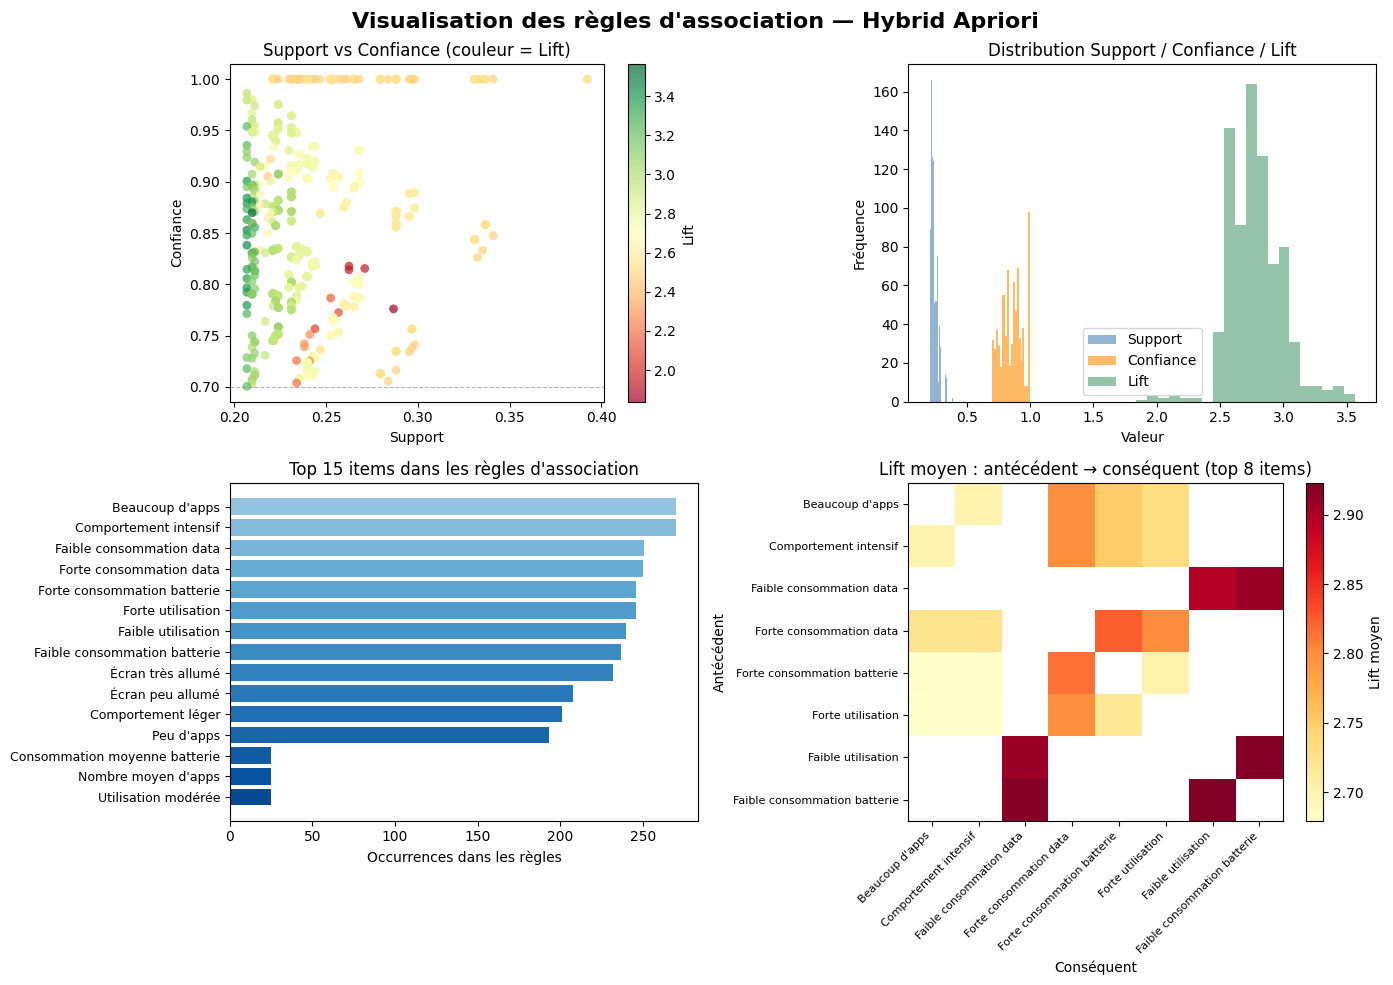

Visualisations sauvegardées dans : visualisations_hybrid_regles.png


In [10]:
# ====================== VISUALIZATION ======================
print("\nGenerating visualizations...")

# Extract metrics from rules
supports_vals   = [r[2] for r in regles]
confiances_vals = [r[3] for r in regles]
lifts_vals      = [r[4] for r in regles]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Visualisation des règles d'association — Hybrid Apriori", 
             fontsize=16, fontweight="bold")

# 1. Scatter: Support vs Confidence (colored by Lift)
ax1 = axes[0, 0]
sc = ax1.scatter(supports_vals, confiances_vals, c=lifts_vals, 
                 cmap="RdYlGn", s=40, alpha=0.7, edgecolors="none")
plt.colorbar(sc, ax=ax1, label="Lift")
ax1.set_xlabel("Support")
ax1.set_ylabel("Confiance")
ax1.set_title("Support vs Confiance (couleur = Lift)")
ax1.axhline(y=0.7, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

# 2. Histograms
ax2 = axes[0, 1]
ax2.hist(supports_vals,   bins=20, alpha=0.6, label="Support",   color="steelblue")
ax2.hist(confiances_vals, bins=20, alpha=0.6, label="Confiance", color="darkorange")
ax2.hist(lifts_vals,      bins=20, alpha=0.5, label="Lift",      color="seagreen")
ax2.set_xlabel("Valeur")
ax2.set_ylabel("Fréquence")
ax2.set_title("Distribution Support / Confiance / Lift")
ax2.legend()

# 3. Top 15 most frequent items in rules
ax3 = axes[1, 0]
all_items = [item for ant, cons, *_ in regles for item in list(ant) + list(cons)]
item_counts = Counter(all_items).most_common(15)
items_noms, items_freq = zip(*item_counts)
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(items_noms)))
ax3.barh(items_noms[::-1], items_freq[::-1], color=colors_bar[::-1])
ax3.set_xlabel("Occurrences dans les règles")
ax3.set_title("Top 15 items dans les règles d'association")
ax3.tick_params(axis="y", labelsize=9)

# 4. Lift heatmap (top 8 items)
ax4 = axes[1, 1]
top_items = [i for i, _ in Counter(all_items).most_common(8)]
matrix = np.zeros((len(top_items), len(top_items)))
counts = np.zeros((len(top_items), len(top_items)), dtype=int)

for ant, cons, sup, conf, lift in regles:
    for a in ant:
        for c in cons:
            if a in top_items and c in top_items:
                i = top_items.index(a)
                j = top_items.index(c)
                matrix[i][j] += lift
                counts[i][j] += 1

with np.errstate(invalid="ignore"):
    avg_lift = np.where(counts > 0, matrix / counts, np.nan)

im = ax4.imshow(avg_lift, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax4, label="Lift moyen")
ax4.set_xticks(range(len(top_items)))
ax4.set_yticks(range(len(top_items)))
ax4.set_xticklabels(top_items, rotation=45, ha="right", fontsize=8)
ax4.set_yticklabels(top_items, fontsize=8)
ax4.set_title("Lift moyen : antécédent → conséquent (top 8 items)")
ax4.set_xlabel("Conséquent")
ax4.set_ylabel("Antécédent")

plt.tight_layout()
plt.savefig("visualisations_hybrid_regles.png", dpi=150, bbox_inches="tight")
plt.show()

print("Visualisations sauvegardées dans : visualisations_hybrid_regles.png")